In [2]:
from src.utils import get_path_MSQDDPM, set_device
from src.MSQDDPM_angel import MSQDDPM, WassDistance
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from tqdm import tqdm
config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './results_MSQDDPM',
        'name': 'CIRCLEY_1',
        # 'transforms': {
        #     'resize': 16
        # },
        'maxsize': 300,
    },
    'model': {
        'n_timesteps': 6,
        'n_zero_ancilla_qubits': 1,
        'n_haar_ancilla_qubits': 1,
        'n_backward_layers': 8,
        'diffusion_schedule': {
            'name': 'linear',
            # 'slope': 2,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}
n_qubits = 1
n_features = 2**n_qubits
diffusion_schedule_nickname = config['model']['diffusion_schedule']['name']
n_zero_ancilla_qubits = config['model']['n_zero_ancilla_qubits']
n_haar_ancilla_qubits = config['model']['n_haar_ancilla_qubits']
n_backward_layers = config['model']['n_backward_layers']
seed = config['seed']
n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
device = set_device(config.get('device', 'cpu'))
torch.set_default_device(device)
get_path = partial(get_path_MSQDDPM, config, diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_zero_ancilla_qubits=n_zero_ancilla_qubits, n_haar_ancilla_qubits=n_haar_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers)
n_limit=0

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


Using device: cpu


In [3]:
# Compute Wasserstein distance across timesteps
device = torch.device('cpu')
torch.set_default_device(device)

dir, filename = get_path(type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname)
dm_diffused = np.load(dir/filename)
print(f"Diffused states shape: {dm_diffused.shape}")
model = MSQDDPM(n_qubits, n_zero_ancilla_qubits, n_haar_ancilla_qubits, n_timesteps, n_backward_layers, seed=seed).to(device)

# Load params
TIMESTEP = 1
params_tot = torch.zeros((n_timesteps, 2*(n_qubits+n_zero_ancilla_qubits+n_haar_ancilla_qubits)*n_backward_layers), device=device)
for tt in range(TIMESTEP, n_timesteps):
    dir, filename = get_path(type='bestparams.npy', t=tt)
    params_tot[tt] = torch.from_numpy(np.load(dir / filename)).to(device)

# Compute the Wasserstein Distance
inputs_last_timestep = torch.from_numpy(dm_diffused[-1]).to(device)
wass = np.zeros(n_timesteps+1)
outputs_timesteps = []
for t in tqdm(range(n_timesteps+1)):
    if t < n_limit:
        continue
    input_tplus1 = model.prepareInput_t(inputs_last_timestep, params_tot, t, n_data)
    measured_full = model.backwardOutput_t(input_tplus1, params_tot[TIMESTEP-1])
    outputs = model._trace_out_ancilla_vmap(measured_full)
    outputs_timesteps.append(outputs.detach().cpu().numpy())
    wass[t] = WassDistance(torch.from_numpy(dm_diffused[0]).to(device), outputs).detach().cpu().numpy()

dir, filename = get_path(type='wassdistbackwardtrain.npy', diffusion_schedule=diffusion_schedule_nickname)
np.save(dir / filename, wass)

# Now of the forward pass
# Wasserstein distance
wass = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps+1)):
    if t < n_limit:
        continue
    np.random.seed()
    wass[t] = WassDistance(torch.from_numpy(dm_diffused[0]).to(device), torch.from_numpy(dm_diffused[t]).to(device)).detach().numpy()

dir, filename = get_path(type='wassdistforward.npy', diffusion_schedule=diffusion_schedule_nickname)
np.save(dir / filename, wass)

Diffused states shape: (7, 300, 2, 2)


100%|██████████| 7/7 [00:00<00:00, 243.25it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward and backward processes')

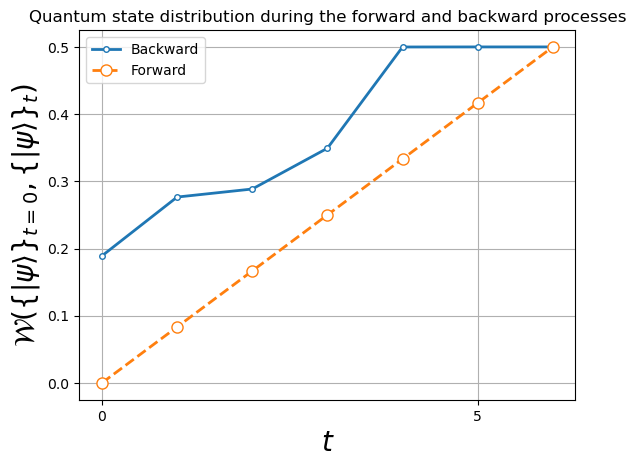

In [4]:
# Plot it

dir, filename = get_path(type='wassdistforward.npy', diffusion_schedule=diffusion_schedule_nickname)
wassforward = np.load(dir / filename)
dir, filename = get_path(type='wassdistbackwardtrain.npy', diffusion_schedule=diffusion_schedule_nickname)
wassbackwardtrain = np.load(dir / filename)

x = list(range(n_limit, n_timesteps+1))
plt.plot(x, wassbackwardtrain[n_limit:], 'o-', label=f'Backward', mfc='white', markersize=4, lw=2)
plt.plot(x, wassforward[n_limit:], 'o--', label='Forward', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.xticks(range(n_limit,n_timesteps+1, 5))
plt.grid(True)
plt.legend()
plt.title(f'Quantum state distribution during the forward and backward processes')

# Bloch visualize

In [5]:
from opt_einsum import contract
from qutip import Bloch
import qutip as qt

def bloch_xyz(rho):
    # obtain bloch sphere representation vector
    # rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

100%|██████████| 7/7 [00:01<00:00,  6.00it/s]


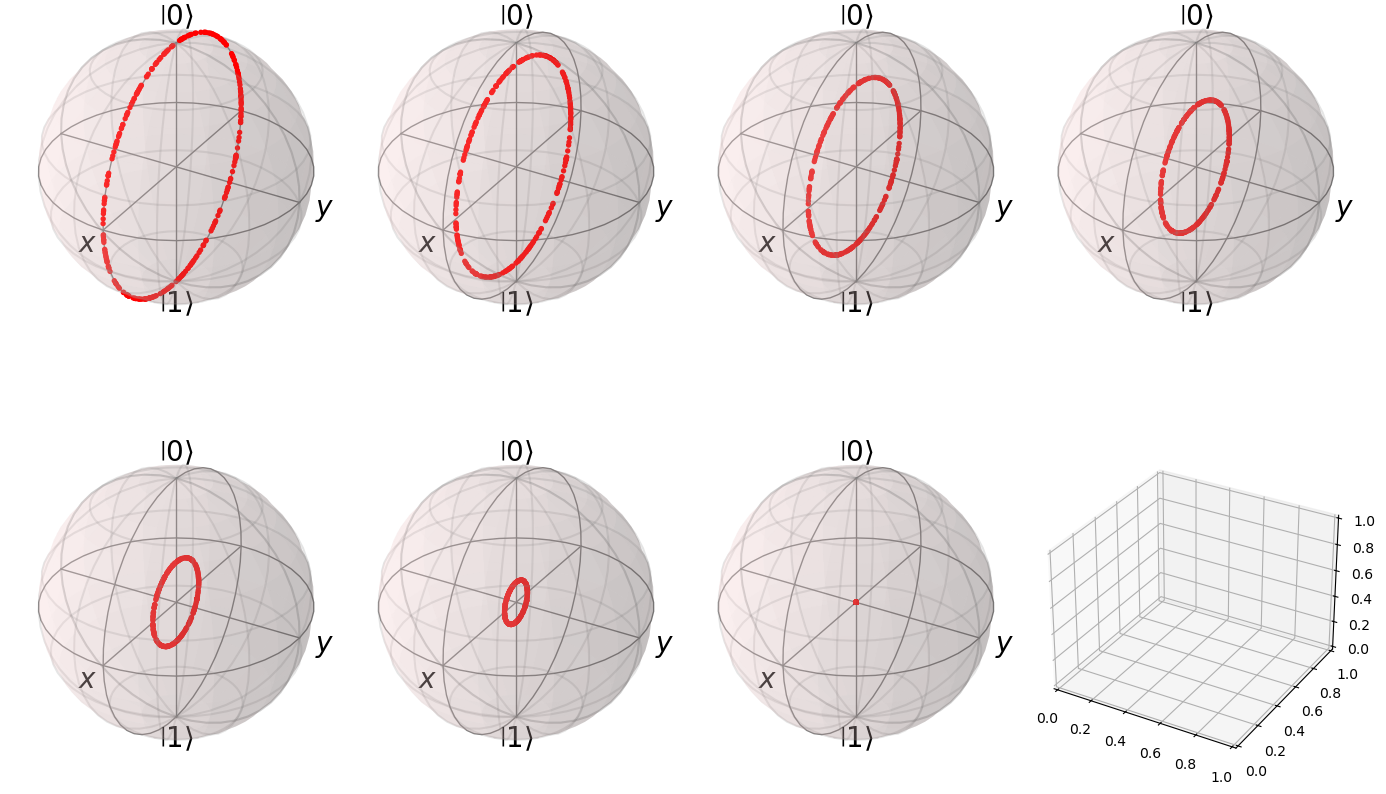

In [6]:
# Bloch visualize on the forward noise process
dir, filename = get_path(type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname)
rhos_diffused = np.load(dir / filename)

rows = 2
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(rhos_diffused[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['r']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

100%|██████████| 7/7 [00:02<00:00,  3.45it/s]


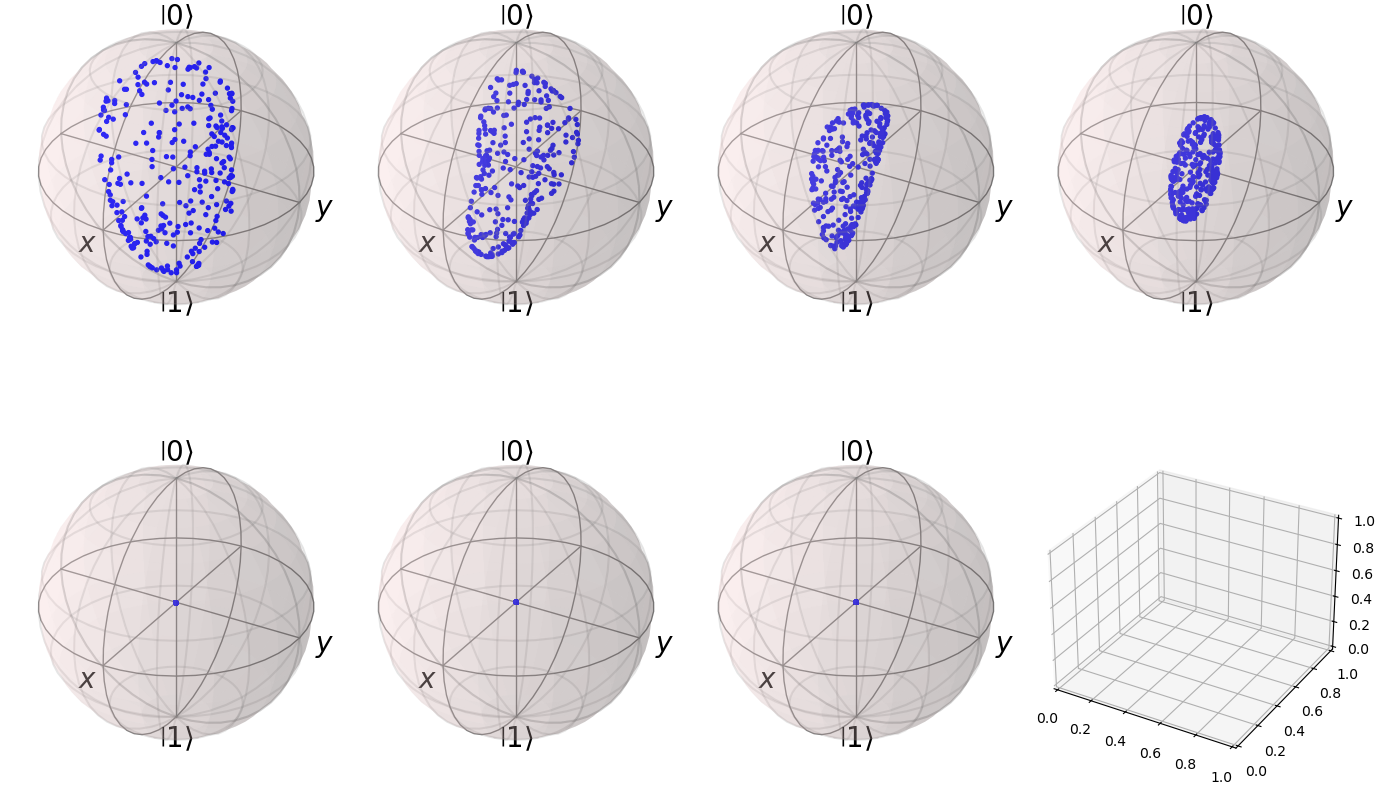

In [10]:
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(outputs_timesteps[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['b']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()